<a href="https://colab.research.google.com/github/MarzzzSiam/CSE414_Project/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CELL 1** — Install All Dependencies

In [ ]:
# CELL 1 — Install all required libraries
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn
!pip install gensim
!pip install tensorflow keras
!pip install wordcloud
!pip install accelerate -U

print("\n All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.6 MB/s eta 0:00:00

 All packages installed successfully!


**CELL 2** — Import All Libraries

In [ ]:
# CELL 2 — Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string

# Sklearn — Classical ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# Deep Learning — Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Bidirectional, Dense,
                                      Dropout, Conv1D, GlobalMaxPooling1D, Input)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Transformers — BanglaBERT
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           get_scheduler)
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Gensim — Word Embeddings
from gensim.models import Word2Vec, FastText

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print("All libraries imported successfully!")
print(f"TensorFlow   : {tf.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

All libraries imported successfully!
TensorFlow   : 2.20.0
PyTorch      : 2.10.0+cu128
GPU available: True


**CELL 3** — Mount Google Drive & Load Dataset

In [ ]:
# CELL 3 — Mount Google Drive and load dataset
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/CSE414_Project/Dataset/train.csv'

df = pd.read_csv(DATASET_PATH)

# Based on your dataset screenshot
TEXT_COLUMN  = 'text'  # Bangla comment column
LABEL_COLUMN = 'y'     # Label column (0, 1, 2)

print("Dataset loaded!")
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print(f"\nLabel distribution:\n{df[LABEL_COLUMN].value_counts()}")
df.head()

Mounted at /content/drive
Dataset loaded!
Shape   : (47817, 3)
Columns : ['id', 'text', 'y']

Label distribution:
y
0    23756
1    18163
2     5898
Name: count, dtype: int64


,id,text,y
0,38389,Woody Allen was expected to be there. If this ...,0
1,32893,বরগলা চোরের,0
2,32527,খা বিমপি জামাত এর হারামিরা,0
3,19617,I'm happy the officer resigned. I saw one post...,1
4,25368,এ পাগল কুতারে কৈও বাদি রাকো নাহয় পাবনায় পাঠিয়ে...,0


**CELL 4** — Language Filtering (Keeping Bangla Only)

In [ ]:
# CELL 4 — Filter predominantly Bangla comments only
def is_bangla(text, threshold=0.4):
    """
    Returns True if at least 40% of characters
    are Bangla Unicode (U+0980 to U+09FF).
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return False
    bangla_chars = len(re.findall(r'[\u0980-\u09FF]', text))
    total_chars  = len(text.replace(' ', ''))
    return (bangla_chars / total_chars) >= threshold if total_chars > 0 else False

before = len(df)
df     = df[df[TEXT_COLUMN].apply(is_bangla)].reset_index(drop=True)
after  = len(df)

print(f"Before filtering : {before:,} samples")
print(f"After  filtering : {after:,} samples")
print(f"Removed          : {before - after:,} non-Bangla comments ({(before-after)/before*100:.1f}%)")
print(f"\nLabel distribution after filter:\n{df[LABEL_COLUMN].value_counts()}")

Before filtering : 47,817 samples
After  filtering : 20,116 samples
Removed          : 27,701 non-Bangla comments (57.9%)

Label distribution after filter:
y
0    11901
1     6769
2     1446
Name: count, dtype: int64


**CELL 5** — Exploratory Data Analysis (EDA)

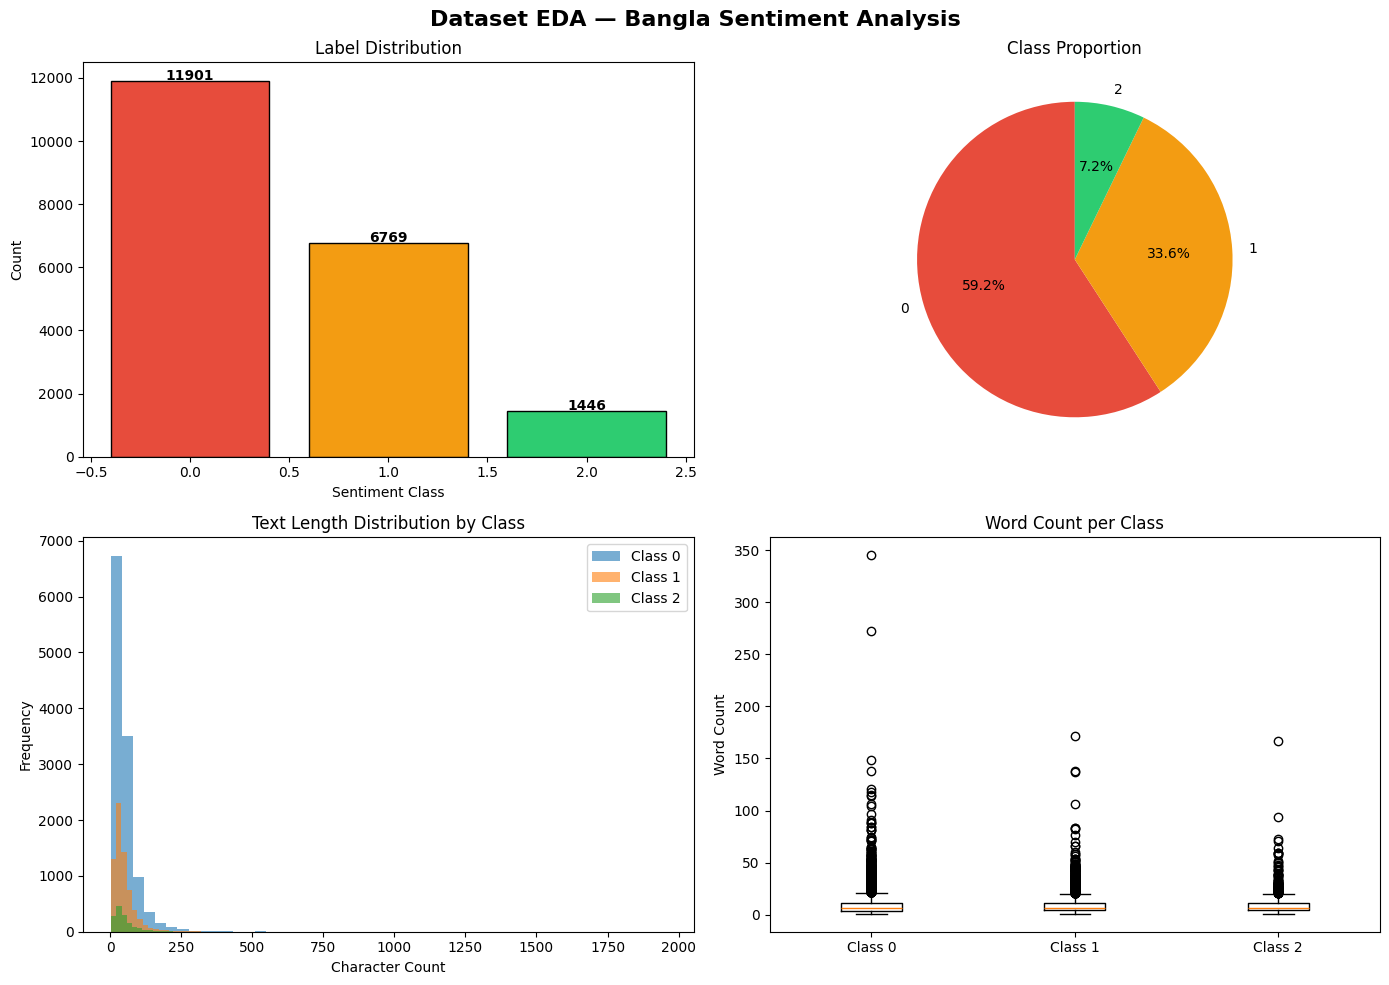


Dataset Summary:
Total samples   : 20,116
Avg text length : 50.7 chars
Avg word count  : 9.0 words
Max word count  : 345 words


In [ ]:
# CELL 5 — Exploratory Data Analysis
df['text_length'] = df[TEXT_COLUMN].astype(str).apply(len)
df['word_count']  = df[TEXT_COLUMN].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset EDA — Bangla Sentiment Analysis', fontsize=16, fontweight='bold')

# 1. Bar chart — label distribution
label_counts = df[LABEL_COLUMN].value_counts()
axes[0, 0].bar(label_counts.index, label_counts.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
axes[0, 0].set_title('Label Distribution')
axes[0, 0].set_xlabel('Sentiment Class')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Pie chart
axes[0, 1].pie(label_counts.values, labels=label_counts.index,
               autopct='%1.1f%%', colors=['#e74c3c', '#f39c12', '#2ecc71'],
               startangle=90)
axes[0, 1].set_title('Class Proportion')

# 3. Text length histogram
for label in df[LABEL_COLUMN].unique():
    subset = df[df[LABEL_COLUMN] == label]['text_length']
    axes[1, 0].hist(subset, bins=50, alpha=0.6, label=f'Class {label}')
axes[1, 0].set_title('Text Length Distribution by Class')
axes[1, 0].set_xlabel('Character Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 4. Word count boxplot
data_by_class = [df[df[LABEL_COLUMN] == label]['word_count'].values
                 for label in sorted(df[LABEL_COLUMN].unique())]
axes[1, 1].boxplot(data_by_class, labels=[f'Class {l}' for l in sorted(df[LABEL_COLUMN].unique())])
axes[1, 1].set_title('Word Count per Class')
axes[1, 1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDataset Summary:")
print(f"Total samples   : {len(df):,}")
print(f"Avg text length : {df['text_length'].mean():.1f} chars")
print(f"Avg word count  : {df['word_count'].mean():.1f} words")
print(f"Max word count  : {df['word_count'].max()} words")

**CELL 6** — Data Preprocessing

In [ ]:
# CELL 6 — Data Preprocessing
def preprocess_bangla_text(text):
    """Full preprocessing pipeline for Bangla social media text."""
    if not isinstance(text, str):
        text = str(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Keep only Bangla Unicode and basic ASCII
    text = re.sub(r'[^\u0980-\u09FF\u0020-\u007E]', ' ', text)
    # Remove punctuation
    text = re.sub(r'[!\"#$%&\'()*+,\-./:;<=>?@\[\\\]^_`{|}~।]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


BANGLA_STOPWORDS = set([
    'এই', 'এটি', 'এটা', 'এবং', 'কিন্তু', 'তবে', 'যে', 'যা', 'সে',
    'তার', 'তাদের', 'আমি', 'আমার', 'আমাদের', 'তুমি', 'তোমার', 'আপনি',
    'আপনার', 'সেই', 'ওই', 'একটি', 'একটা', 'করা', 'করে', 'করেছে',
    'হয়', 'হয়েছে', 'হবে', 'হওয়া', 'ছিল', 'ছিলো', 'আছে', 'আছেন',
    'না', 'নয়', 'নেই', 'থেকে', 'পর্যন্ত', 'জন্য', 'দিয়ে', 'দিকে',
    'সাথে', 'মধ্যে', 'উপর', 'নিচে', 'আগে', 'পরে', 'কি', 'কী', 'কেন',
    'কোথায়', 'কখন', 'কীভাবে', 'যখন', 'তখন', 'যদি', 'তাহলে', 'অথবা',
    'বা', 'ও', 'খুব', 'অনেক', 'কিছু', 'সব', 'প্রতি', 'আর', 'তো'
])

def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in BANGLA_STOPWORDS])


print("⏳ Preprocessing text...")
df['cleaned_text'] = df[TEXT_COLUMN].apply(preprocess_bangla_text)
df['cleaned_text'] = df['cleaned_text'].apply(remove_stopwords)

# Drop empty rows after cleaning
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)

print(f"Preprocessing done! Samples remaining: {len(df):,}")
print(f"\nBefore: {df[TEXT_COLUMN].iloc[0]}")
print(f"After : {df['cleaned_text'].iloc[0]}")

⏳ Preprocessing text...
Preprocessing done! Samples remaining: 20,116

Before: বরগলা চোরের
After : বরগলা চোরের


**CELL 7** — Label Encoding & Train/Test Split

In [ ]:
# CELL 7 — Label Encoding and Train/Test Split

# Labels are already numeric (0, 1, 2) based on the dataset
# 0 = explicitly toxic, 1 = subtly toxic, 2 = neutral

le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df[LABEL_COLUMN])

print("Label encoding:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {idx}")

X = df['cleaned_text'].values
y = df['encoded_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

NUM_CLASSES = len(le.classes_)
CLASS_NAMES = [str(c) for c in le.classes_]

print(f"\nSplit done!")
print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")
print(f"Classes          : {CLASS_NAMES}")

Label encoding:
  0 → 0
  1 → 1
  2 → 2

Split done!
Training samples : 16,092
Testing  samples : 4,024
Classes          : ['0', '1', '2']


**CELL 8** — Feature Extraction (BoW + TF-IDF)

In [ ]:
# CELL 8 — Feature Extraction for Classical ML models

# Bag of Words
bow_vectorizer = CountVectorizer(max_features=30000, ngram_range=(1, 2))
X_train_bow    = bow_vectorizer.fit_transform(X_train)
X_test_bow     = bow_vectorizer.transform(X_test)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf    = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf     = tfidf_vectorizer.transform(X_test)

print("Feature extraction done!")
print(f"BoW    shape : {X_train_bow.shape}")
print(f"TF-IDF shape : {X_train_tfidf.shape}")

Feature extraction done!
BoW    shape : (16092, 30000)
TF-IDF shape : (16092, 30000)


**CELL 9** — `Tier 1` Classical ML Models

In [ ]:
# CELL 9 — Train Classical ML Models
results = {}  # stores all model results

def evaluate_model(name, y_true, y_pred):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'F1-Score':  round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
    }

# 1. Naive Bayes (BoW)
print("Training Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_bow, y_train)
nb_pred  = nb_model.predict(X_test_bow)
results['Naive Bayes'] = evaluate_model('Naive Bayes', y_test, nb_pred)
print(f"   Accuracy: {results['Naive Bayes']['Accuracy']}%")

# 2. Logistic Regression (TF-IDF)
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred  = lr_model.predict(X_test_tfidf)
results['Logistic Regression'] = evaluate_model('Logistic Regression', y_test, lr_pred)
print(f"   Accuracy: {results['Logistic Regression']['Accuracy']}%")

# 3. SVM (TF-IDF)
print(" Training SVM (LinearSVC)...")
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred  = svm_model.predict(X_test_tfidf)
results['SVM'] = evaluate_model('SVM', y_test, svm_pred)
print(f"   Accuracy: {results['SVM']['Accuracy']}%")

print("\nTier 1 — Classical ML training complete!")

Training Naive Bayes...
   Accuracy: 55.94%
Training Logistic Regression...
   Accuracy: 57.73%
 Training SVM (LinearSVC)...
   Accuracy: 56.81%

Tier 1 — Classical ML training complete!


**CELL 10** — Word Embeddings (Word2Vec + FastText + Keras Tokenizer)

In [ ]:
# CELL 10 — Train Word2Vec, FastText and prepare Keras sequences
tokenized_corpus = [text.split() for text in X_train]

# Word2Vec
print("Training Word2Vec...")
w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100, window=5, min_count=2,
    workers=4, epochs=10, sg=1
)
print(f"   Word2Vec vocab: {len(w2v_model.wv):,} words")

# FastText
print("Training FastText...")
ft_model = FastText(
    sentences=tokenized_corpus,
    vector_size=100, window=5, min_count=2,
    workers=4, epochs=10, sg=1
)
print(f"   FastText vocab: {len(ft_model.wv):,} words")

# Keras Tokenizer
MAX_WORDS = 50000
MAX_LEN   = 100
EMBED_DIM = 100

keras_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(keras_tokenizer.texts_to_sequences(X_train),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(keras_tokenizer.texts_to_sequences(X_test),
                             maxlen=MAX_LEN, padding='post', truncating='post')

print(f"   Padded shape: {X_train_pad.shape}")

# Build Embedding Matrices
word_index = keras_tokenizer.word_index
VOCAB_SIZE  = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix_w2v = np.zeros((VOCAB_SIZE, EMBED_DIM))
embedding_matrix_ft  = np.zeros((VOCAB_SIZE, EMBED_DIM))

for word, idx in word_index.items():
    if idx >= MAX_WORDS:
        continue
    if word in w2v_model.wv:
        embedding_matrix_w2v[idx] = w2v_model.wv[word]
    if word in ft_model.wv:
        embedding_matrix_ft[idx]  = ft_model.wv[word]

print(f"   Embedding matrices ready: {embedding_matrix_w2v.shape}")

Training Word2Vec...
   Word2Vec vocab: 10,032 words
Training FastText...
   FastText vocab: 10,032 words
   Padded shape: (16092, 100)
   Embedding matrices ready: (24710, 100)


**CELL 11** — `Tier 2` CNN Model

In [ ]:
# CELL 11 — CNN Text Classification Model
def build_cnn_model(embedding_matrix, vocab_size, embed_dim, max_len, num_classes):
    inputs = Input(shape=(max_len,))
    x = Embedding(vocab_size, embed_dim,
                  weights=[embedding_matrix], trainable=False)(inputs)

    # Multiple filter sizes to capture different n-gram patterns
    conv2 = Conv1D(128, kernel_size=2, activation='relu', padding='same')(x)
    conv3 = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    conv4 = Conv1D(128, kernel_size=4, activation='relu', padding='same')(x)

    pool2 = GlobalMaxPooling1D()(conv2)
    pool3 = GlobalMaxPooling1D()(conv3)
    pool4 = GlobalMaxPooling1D()(conv4)

    concat  = tf.keras.layers.concatenate([pool2, pool3, pool4])
    x       = Dense(128, activation='relu')(concat)
    x       = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


print("Training CNN model...")
cnn_model = build_cnn_model(embedding_matrix_ft, VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
cnn_model.summary()

cnn_history = cnn_model.fit(
    X_train_pad, y_train,
    epochs=10, batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

cnn_pred = np.argmax(cnn_model.predict(X_test_pad), axis=1)
results['CNN'] = evaluate_model('CNN', y_test, cnn_pred)
print(f"\nCNN Accuracy: {results['CNN']['Accuracy']}%")

Training CNN model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │  2,471,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 100, 128)  │     25,728 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 128)  │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 100, 128)  │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,636,251 (10.06 MB)

 Trainable params: 165,251 (645.51 KB)

 Non-trainable params: 2,471,000 (9.43 MB)

Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.5853 - loss: 0.8510 - val_accuracy: 0.5851 - val_loss: 0.8482
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5893 - loss: 0.8271 - val_accuracy: 0.5857 - val_loss: 0.8429
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5923 - loss: 0.8199 - val_accuracy: 0.5876 - val_loss: 0.8382
Epoch 4/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5976 - loss: 0.8118 - val_accuracy: 0.5839 - val_loss: 0.8383
Epoch 5/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6044 - loss: 0.8030 - val_accuracy: 0.5845 - val_loss: 0.8381
Epoch 6/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6016 - loss: 0.7941 - val_accuracy: 0.5882 - val_loss: 0.8330
Epoch 7/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6072 - loss: 0.7820 - val_accuracy: 0.5776 - val_loss: 0.8390
Epoch 8/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6148 - loss: 0.7696 - val_accuracy: 

**CELL 12** — `Tier 2` BiLSTM Model

In [ ]:
# CELL 12 — Bidirectional LSTM Model
def build_bilstm_model(embedding_matrix, vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim,
                  weights=[embedding_matrix],
                  input_length=max_len,
                  trainable=False),
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)),
        Bidirectional(LSTM(64, dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


print("⏳ Training BiLSTM model...")
bilstm_model = build_bilstm_model(embedding_matrix_w2v, VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
bilstm_model.summary()

bilstm_history = bilstm_model.fit(
    X_train_pad, y_train,
    epochs=10, batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

bilstm_pred = np.argmax(bilstm_model.predict(X_test_pad), axis=1)
results['BiLSTM'] = evaluate_model('BiLSTM', y_test, bilstm_pred)
print(f"\nBiLSTM Accuracy: {results['BiLSTM']['Accuracy']}%")

⏳ Training BiLSTM model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     2,471,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,471,000 (9.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,471,000 (9.43 MB)

Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.5766 - loss: 0.8723 - val_accuracy: 0.5851 - val_loss: 0.8506
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.5867 - loss: 0.8443 - val_accuracy: 0.5851 - val_loss: 0.8490
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5909 - loss: 0.8401 - val_accuracy: 0.5851 - val_loss: 0.8446
Epoch 4/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5925 - loss: 0.8364 - val_accuracy: 0.5851 - val_loss: 0.8456
Epoch 5/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5918 - loss: 0.8344 - val_accuracy: 0.5851 - val_loss: 0.8426
Epoch 6/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5918 - loss: 0.8323 - val_accuracy: 0.5851 - val_loss: 0.8401
Epoch 7/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5926 - loss: 0.8296 - val_accuracy: 0.5857 - val_loss: 0.8417
Epoch 8/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5938 - loss: 0.8282 - val_acc

**CELL 13** — `Tier 3` BanglaBERT Fine-tuning

In [ ]:
# CELL 13 — BanglaBERT Fine-tuning
class BanglaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


MODEL_NAME = 'sagorsarker/bangla-bert-base'
print(f"Loading {MODEL_NAME}...")

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
bert_model = bert_model.to(device)

train_loader = DataLoader(BanglaDataset(X_train.tolist(), y_train.tolist(), bert_tokenizer),
                          batch_size=16, shuffle=True)
test_loader  = DataLoader(BanglaDataset(X_test.tolist(),  y_test.tolist(),  bert_tokenizer),
                          batch_size=16, shuffle=False)

EPOCHS    = 3
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
num_steps = EPOCHS * len(train_loader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer,
                               num_warmup_steps=int(0.1 * num_steps),
                               num_training_steps=num_steps)

print("\nFine-tuning BanglaBERT...")
for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = bert_model(
            input_ids      = batch['input_ids'].to(device),
            attention_mask = batch['attention_mask'].to(device),
            labels         = batch['labels'].to(device)
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        lr_scheduler.step()
        total_loss += out.loss.item()
    print(f"  Epoch {epoch+1}/{EPOCHS} — Avg Loss: {total_loss/len(train_loader):.4f}")

print("\nEvaluating BanglaBERT...")
bert_model.eval()
bert_preds = []
with torch.no_grad():
    for batch in test_loader:
        out = bert_model(
            input_ids      = batch['input_ids'].to(device),
            attention_mask = batch['attention_mask'].to(device)
        )
        bert_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())

bert_pred = np.array(bert_preds)
results['BanglaBERT'] = evaluate_model('BanglaBERT', y_test, bert_pred)
print(f"\nBanglaBERT Accuracy: {results['BanglaBERT']['Accuracy']}%")

# Save to Drive
bert_model.save_pretrained('/content/drive/MyDrive/CSE414_Project/banglabert_finetuned')
bert_tokenizer.save_pretrained('/content/drive/MyDrive/CSE414_Project/banglabert_finetuned')
print("Model saved to Google Drive!")

Loading sagorsarker/bangla-bert-base...


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda

Fine-tuning BanglaBERT...
  Epoch 1/3 — Avg Loss: 0.8458
  Epoch 2/3 — Avg Loss: 0.7301
  Epoch 3/3 — Avg Loss: 0.5647

Evaluating BanglaBERT...

BanglaBERT Accuracy: 58.42%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to Google Drive!


**CELL 14** — Cross-Validation (Classical Models)

Running 5-fold cross-validation...

Logistic Regression  CV F1: 50.53% ± 0.34%
SVM                  CV F1: 51.56% ± 0.39%
Naive Bayes          CV F1: 50.23% ± 0.33%


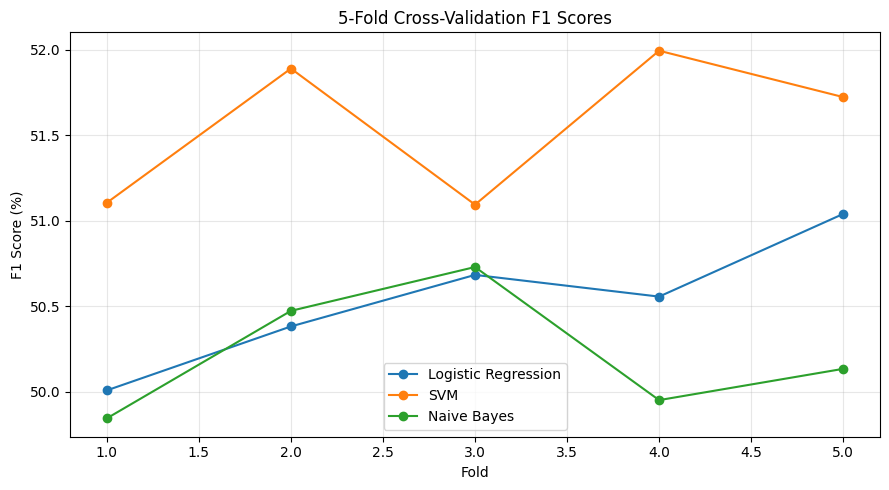

Cross-validation complete!


In [ ]:
# CELL 14 — 5-Fold Cross-Validation
print("Running 5-fold cross-validation...\n")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

lr_cv = cross_val_score(
    Pipeline([('tfidf', TfidfVectorizer(max_features=30000)),
              ('clf',   LogisticRegression(max_iter=1000))]),
    X, y, cv=skf, scoring='f1_weighted')
cv_results['Logistic Regression'] = lr_cv
print(f"Logistic Regression  CV F1: {lr_cv.mean()*100:.2f}% ± {lr_cv.std()*100:.2f}%")

svm_cv = cross_val_score(
    Pipeline([('tfidf', TfidfVectorizer(max_features=30000)),
              ('clf',   LinearSVC(max_iter=2000))]),
    X, y, cv=skf, scoring='f1_weighted')
cv_results['SVM'] = svm_cv
print(f"SVM                  CV F1: {svm_cv.mean()*100:.2f}% ± {svm_cv.std()*100:.2f}%")

nb_cv = cross_val_score(
    Pipeline([('bow', CountVectorizer(max_features=30000)),
              ('clf', MultinomialNB())]),
    X, y, cv=skf, scoring='f1_weighted')
cv_results['Naive Bayes'] = nb_cv
print(f"Naive Bayes          CV F1: {nb_cv.mean()*100:.2f}% ± {nb_cv.std()*100:.2f}%")

# Plot CV scores
fig, ax = plt.subplots(figsize=(9, 5))
for model_name, scores in cv_results.items():
    ax.plot(range(1, 6), scores * 100, marker='o', label=model_name)
ax.set_title('5-Fold Cross-Validation F1 Scores')
ax.set_xlabel('Fold')
ax.set_ylabel('F1 Score (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150)
plt.show()
print("Cross-validation complete!")

**CELL 15** — Full Results Comparison Table

In [ ]:
# CELL 15 — Full Results Comparison Table
results_df = pd.DataFrame(results.values())
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df.index += 1

print("=" * 68)
print("           FULL MODEL COMPARISON RESULTS")
print("=" * 68)
print(results_df.to_string())
print("=" * 68)
print(f"\nBest Model : {results_df.iloc[0]['Model']}")
print(f"   F1-Score   : {results_df.iloc[0]['F1-Score']}%")
print(f"   Accuracy   : {results_df.iloc[0]['Accuracy']}%")

           FULL MODEL COMPARISON RESULTS
                 Model  Accuracy  Precision  Recall  F1-Score
1           BanglaBERT     58.42      56.22   58.42     56.87
2                  SVM     56.81      52.31   56.81     52.87
3          Naive Bayes     55.94      51.34   55.94     52.16
4  Logistic Regression     57.73      51.83   57.73     50.87
5                  CNN     59.15      53.16   59.15     46.39
6               BiLSTM     59.27      61.81   59.27     44.27

Best Model : BanglaBERT
   F1-Score   : 56.87%
   Accuracy   : 58.42%


**CELL 16** — Confusion Matrices (All Models)

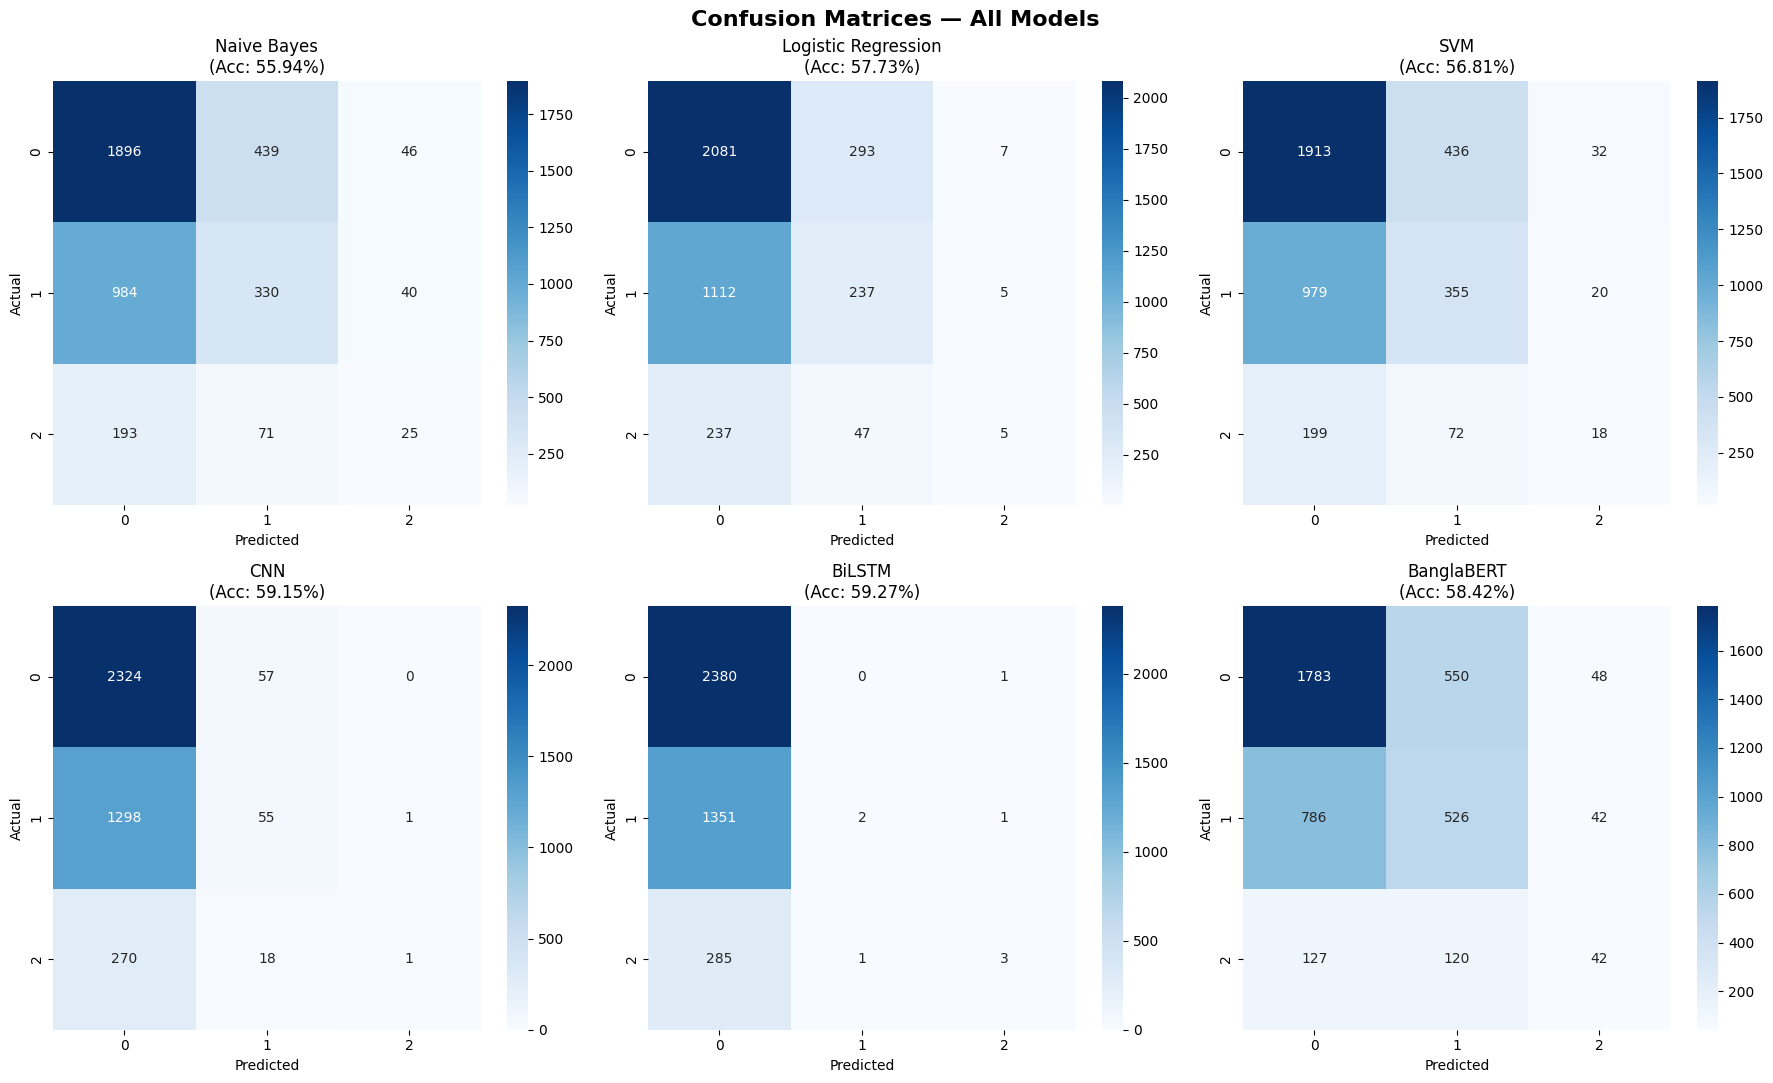

Confusion matrices saved!


In [ ]:
# CELL 16 — Confusion Matrices for all models
all_preds_dict = {
    'Naive Bayes':         nb_pred,
    'Logistic Regression': lr_pred,
    'SVM':                 svm_pred,
    'CNN':                 cnn_pred,
    'BiLSTM':              bilstm_pred,
    'BanglaBERT':          bert_pred,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, (model_name, preds) in enumerate(all_preds_dict.items()):
    cm  = confusion_matrix(y_test, preds)
    acc = accuracy_score(y_test, preds) * 100
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                ax=axes[idx])
    axes[idx].set_title(f'{model_name}\n(Acc: {acc:.2f}%)')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

**CELL 17** — Performance Bar Charts

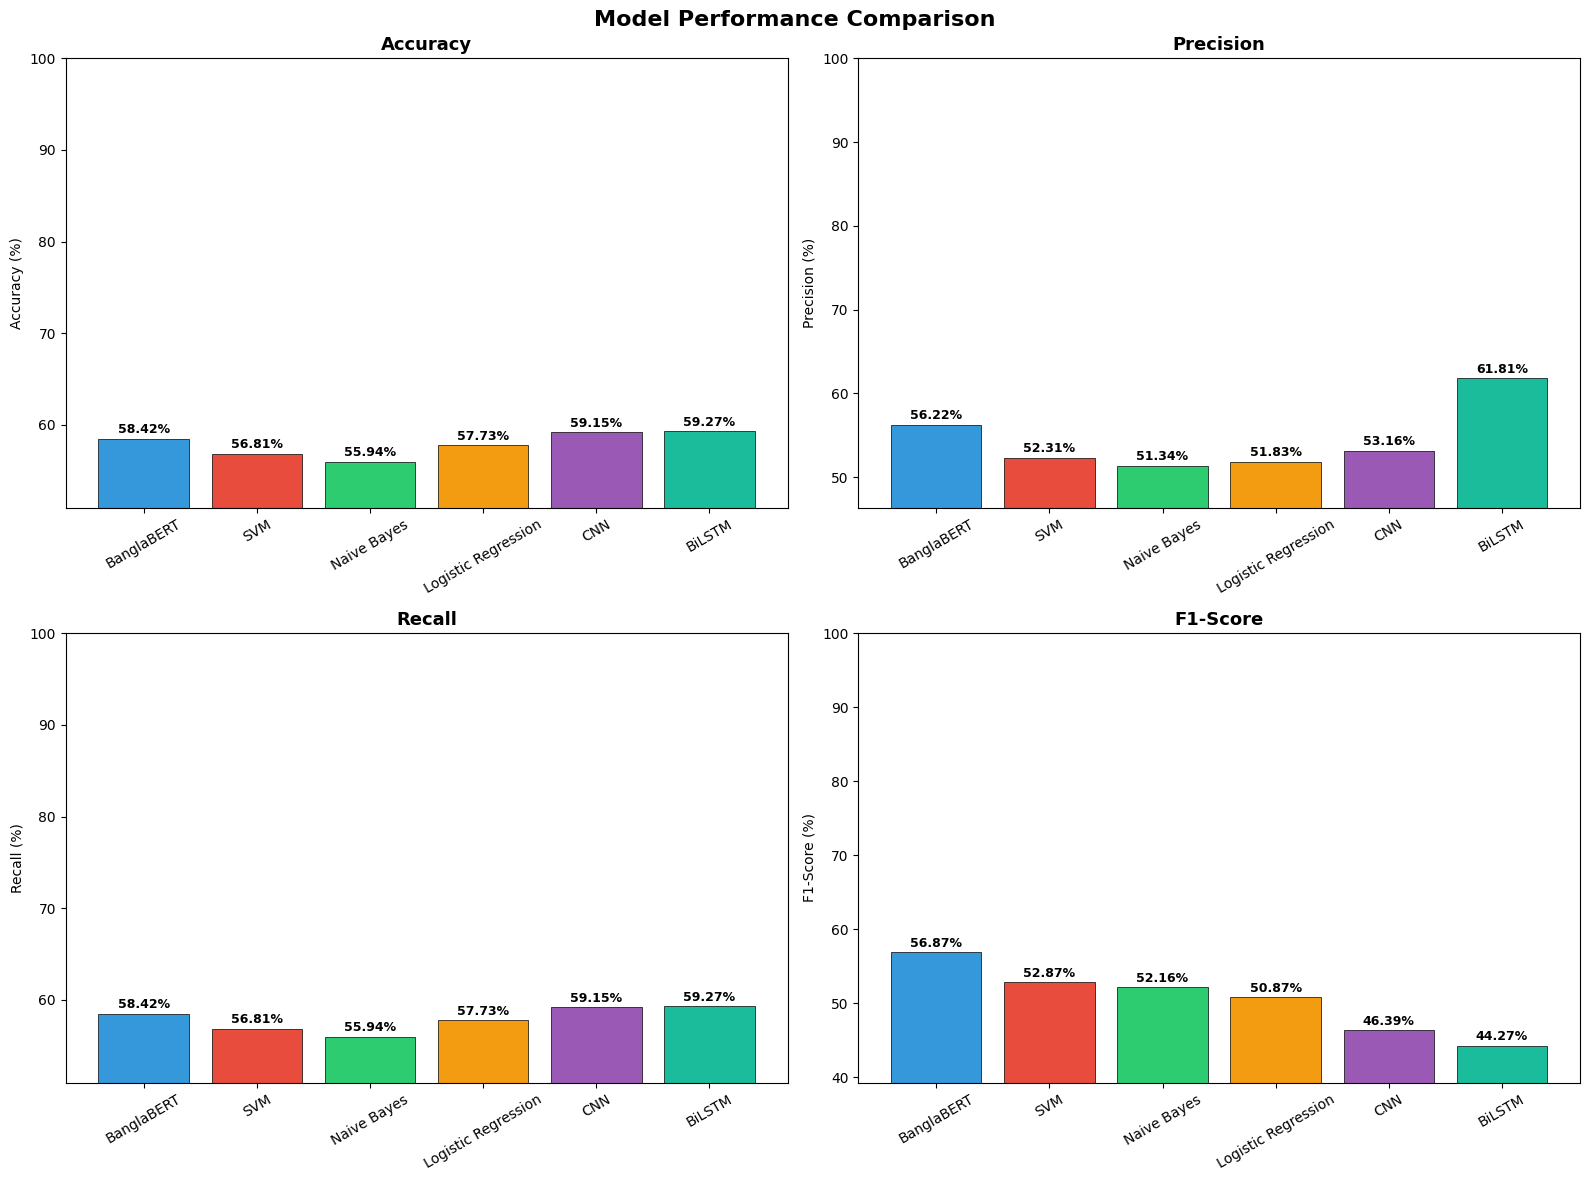

Performance comparison chart saved!


In [ ]:
# CELL 17 — Performance Bar Charts
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = results_df['Model'].tolist()
colors      = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, metric in enumerate(metrics):
    values = results_df[metric].tolist()
    bars   = axes[i].bar(model_names, values,
                          color=colors[:len(model_names)],
                          edgecolor='black', linewidth=0.5)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel(f'{metric} (%)')
    axes[i].set_ylim([max(0, min(values) - 5), 100])
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width() / 2.,
                      bar.get_height() + 0.3,
                      f'{val}%', ha='center', va='bottom',
                      fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Performance comparison chart saved!")

**CELL 18** — Ablation Study

           ABLATION STUDY RESULTS
             Experiment  Accuracy  F1-Score
               LR + BoW     57.83     52.24
            LR + TF-IDF     57.73     50.87
         CNN + FastText     59.15     46.39
      BiLSTM + Word2Vec     59.27     44.27
BanglaBERT (Fine-tuned)     58.42     56.87


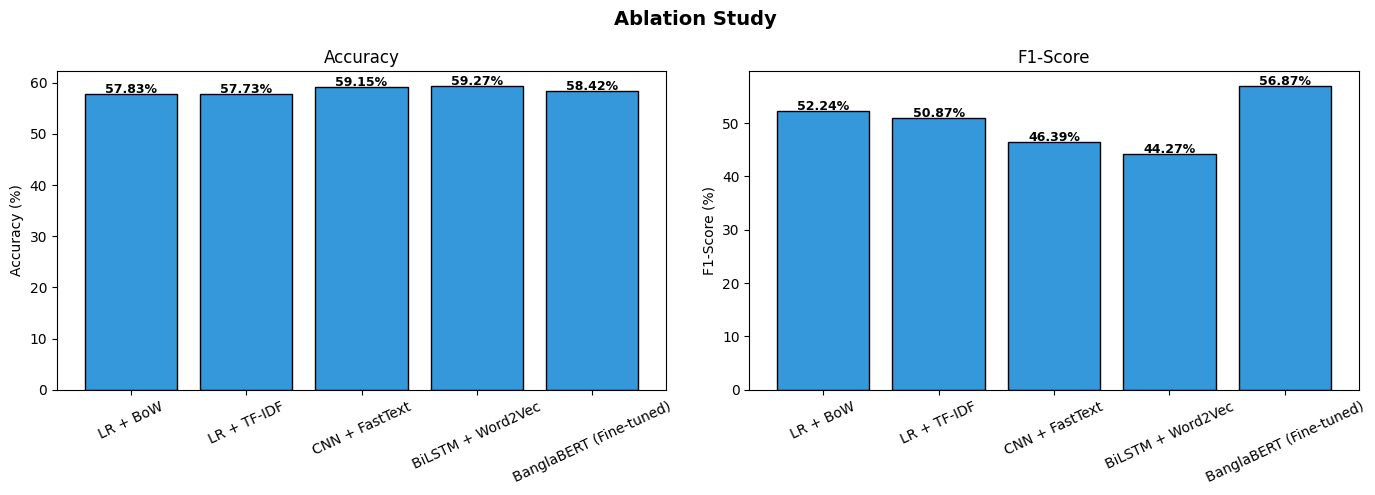

Ablation study saved!


In [ ]:
# CELL 18 — Ablation Study
ablation_results = []

# BoW vs TF-IDF on Logistic Regression
lr_bow   = LogisticRegression(max_iter=1000).fit(X_train_bow, y_train)
pred_bow = lr_bow.predict(X_test_bow)

ablation_results.append({'Experiment': 'LR + BoW',
    'Accuracy': round(accuracy_score(y_test, pred_bow) * 100, 2),
    'F1-Score': round(f1_score(y_test, pred_bow, average='weighted') * 100, 2)})
ablation_results.append({'Experiment': 'LR + TF-IDF',
    'Accuracy': results['Logistic Regression']['Accuracy'],
    'F1-Score': results['Logistic Regression']['F1-Score']})
ablation_results.append({'Experiment': 'CNN + FastText',
    'Accuracy': results['CNN']['Accuracy'],
    'F1-Score': results['CNN']['F1-Score']})
ablation_results.append({'Experiment': 'BiLSTM + Word2Vec',
    'Accuracy': results['BiLSTM']['Accuracy'],
    'F1-Score': results['BiLSTM']['F1-Score']})
ablation_results.append({'Experiment': 'BanglaBERT (Fine-tuned)',
    'Accuracy': results['BanglaBERT']['Accuracy'],
    'F1-Score': results['BanglaBERT']['F1-Score']})

ablation_df = pd.DataFrame(ablation_results)
print("=" * 55)
print("           ABLATION STUDY RESULTS")
print("=" * 55)
print(ablation_df.to_string(index=False))
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Study', fontsize=14, fontweight='bold')
for ax, metric in zip(axes, ['Accuracy', 'F1-Score']):
    bars = ax.bar(ablation_df['Experiment'], ablation_df[metric],
                   color='#3498db', edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(f'{metric} (%)')
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, ablation_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2.,
                 bar.get_height() + 0.2,
                 f'{val}%', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ablation study saved!")

**CELL 19** — Classification Reports

In [ ]:
# CELL 19 — Detailed Classification Reports
for model_name, preds in all_preds_dict.items():
    print(f"\n{'='*55}")
    print(f"  {model_name} — Classification Report")
    print(f"{'='*55}")
    print(classification_report(y_test, preds, target_names=CLASS_NAMES))


  Naive Bayes — Classification Report
              precision    recall  f1-score   support

           0       0.62      0.80      0.70      2381
           1       0.39      0.24      0.30      1354
           2       0.23      0.09      0.12       289

    accuracy                           0.56      4024
   macro avg       0.41      0.38      0.37      4024
weighted avg       0.51      0.56      0.52      4024


  Logistic Regression — Classification Report
              precision    recall  f1-score   support

           0       0.61      0.87      0.72      2381
           1       0.41      0.18      0.25      1354
           2       0.29      0.02      0.03       289

    accuracy                           0.58      4024
   macro avg       0.44      0.36      0.33      4024
weighted avg       0.52      0.58      0.51      4024


  SVM — Classification Report
              precision    recall  f1-score   support

           0       0.62      0.80      0.70      2381
           1

**CELL 20** — DL Training History Plots

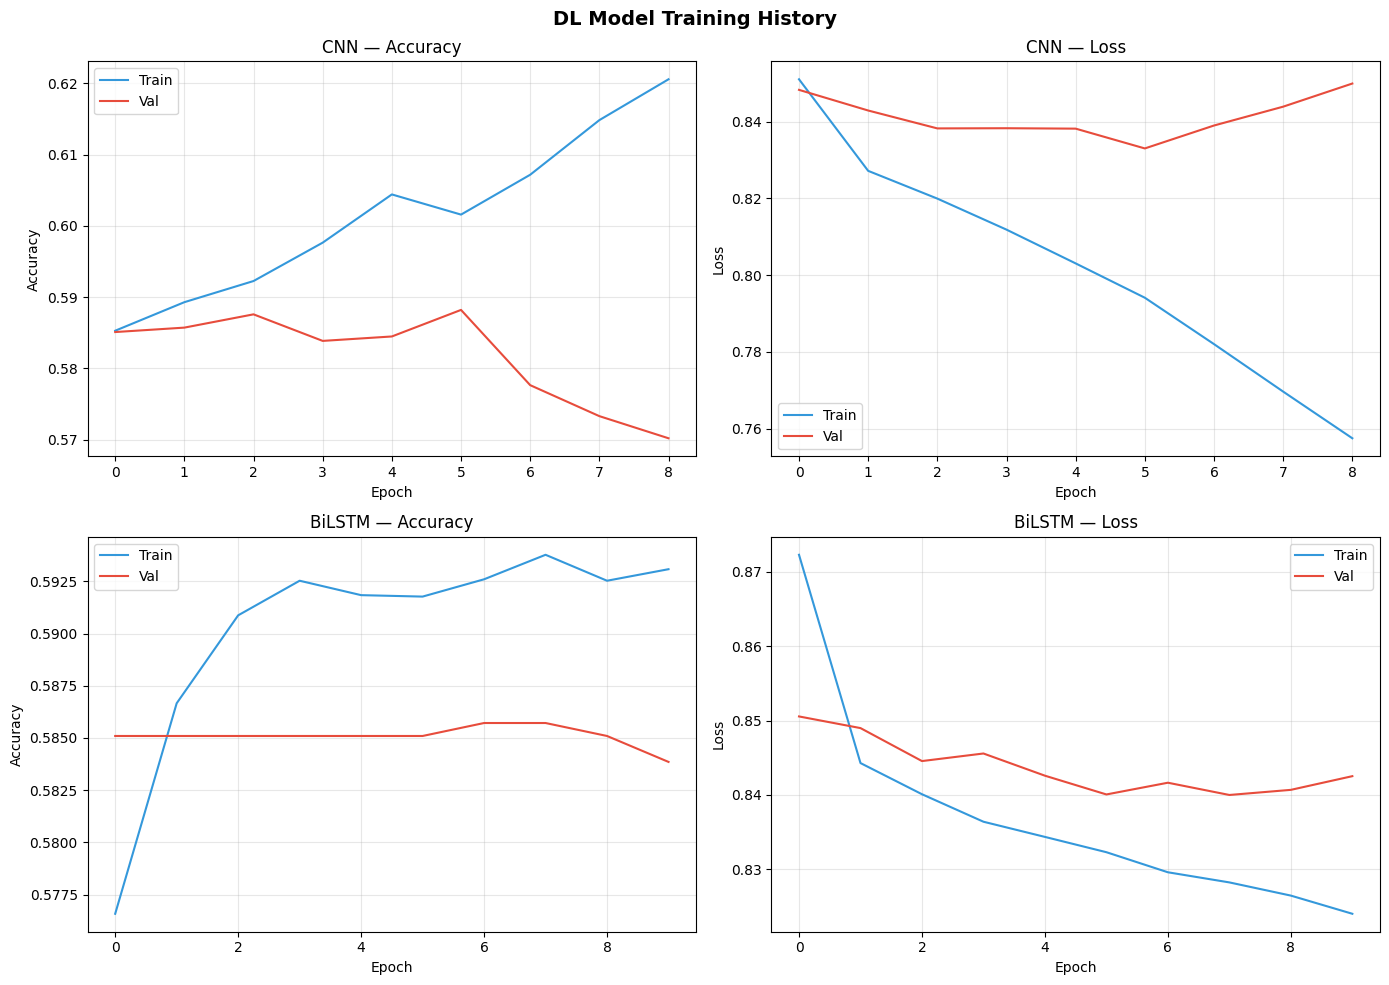

Training history plots saved!


In [ ]:
# CELL 20 — Training History Plots for CNN and BiLSTM
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DL Model Training History', fontsize=14, fontweight='bold')

for i, (name, history) in enumerate([('CNN', cnn_history), ('BiLSTM', bilstm_history)]):
    axes[i, 0].plot(history.history['accuracy'],     label='Train', color='#3498db')
    axes[i, 0].plot(history.history['val_accuracy'], label='Val',   color='#e74c3c')
    axes[i, 0].set_title(f'{name} — Accuracy')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Accuracy')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(history.history['loss'],     label='Train', color='#3498db')
    axes[i, 1].plot(history.history['val_loss'], label='Val',   color='#e74c3c')
    axes[i, 1].set_title(f'{name} — Loss')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history plots saved!")

**CELL 21** — Live Prediction Demo

In [ ]:
# CELL 21 — Live Prediction Demo
def predict_sentiment(text, model_choice='banglabert'):
    """
    model_choice: 'banglabert', 'bilstm', 'cnn', 'svm', 'lr', 'nb'
    """
    cleaned = remove_stopwords(preprocess_bangla_text(text))

    if model_choice == 'banglabert':
        bert_model.eval()
        enc = bert_tokenizer(cleaned, max_length=128, padding='max_length',
                              truncation=True, return_tensors='pt')
        with torch.no_grad():
            out = bert_model(input_ids=enc['input_ids'].to(device),
                              attention_mask=enc['attention_mask'].to(device))
        pred_idx = torch.argmax(out.logits, dim=1).item()

    elif model_choice == 'bilstm':
        seq      = keras_tokenizer.texts_to_sequences([cleaned])
        pad      = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
        pred_idx = np.argmax(bilstm_model.predict(pad, verbose=0), axis=1)[0]

    elif model_choice == 'cnn':
        seq      = keras_tokenizer.texts_to_sequences([cleaned])
        pad      = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
        pred_idx = np.argmax(cnn_model.predict(pad, verbose=0), axis=1)[0]

    elif model_choice == 'svm':
        pred_idx = svm_model.predict(tfidf_vectorizer.transform([cleaned]))[0]

    elif model_choice == 'lr':
        pred_idx = lr_model.predict(tfidf_vectorizer.transform([cleaned]))[0]

    elif model_choice == 'nb':
        pred_idx = nb_model.predict(bow_vectorizer.transform([cleaned]))[0]

    return CLASS_NAMES[pred_idx]


# Test comments
test_comments = [
    "এই পণ্যটি অসাধারণ, আমি খুব খুশি",
    "তুমি একদম বাজে মানুষ, ঘৃণা করি",
    "ঠিক আছে, মোটামুটি ভালো বলা যায়",
]

print("Live Prediction Demo (BanglaBERT)\n" + "="*50)
for comment in test_comments:
    result = predict_sentiment(comment, model_choice='banglabert')
    print(f"Comment  : {comment}")
    print(f"Predicted: {result}\n")

# Try own
print("="*50)
my_comment = "হারামজাদা"
print(f"Comment  : {my_comment}")
print(f"Predicted: {predict_sentiment(my_comment, model_choice='banglabert')}")

Live Prediction Demo (BanglaBERT)
Comment  : এই পণ্যটি অসাধারণ, আমি খুব খুশি
Predicted: 1

Comment  : তুমি একদম বাজে মানুষ, ঘৃণা করি
Predicted: 2

Comment  : ঠিক আছে, মোটামুটি ভালো বলা যায়
Predicted: 0

Comment  : হারামজাদা
Predicted: 0
